# The Complex Environment (Multi-Target & Doppler, the "Bat Prey")

This implementation tests the robustness and limits of our system.

Cell 1 is the standard numpy-based transmitter.

Cell 2 is where the new physics lives. We create two targets:

A stationary wall at 5 meters.

A moving post at 3 meters, traveling away from us at 10 m/s.

The moving post causes a Doppler Shift on the echo's carrier frequency.

The receiver is simple: it only knows the original carrier frequency. It tries to demodulate both signals.

Cell 3 runs the same matched filter as before. We will see it finds the stationary target perfectly, but the moving target's signal is smeared and attenuated because of the frequency mismatch.

### Cell 1: The Neural Transmitter (Standard numpy Version)

This cell is the same as in our first 1D experiment. It generates the spike train and the final transmitted signal.

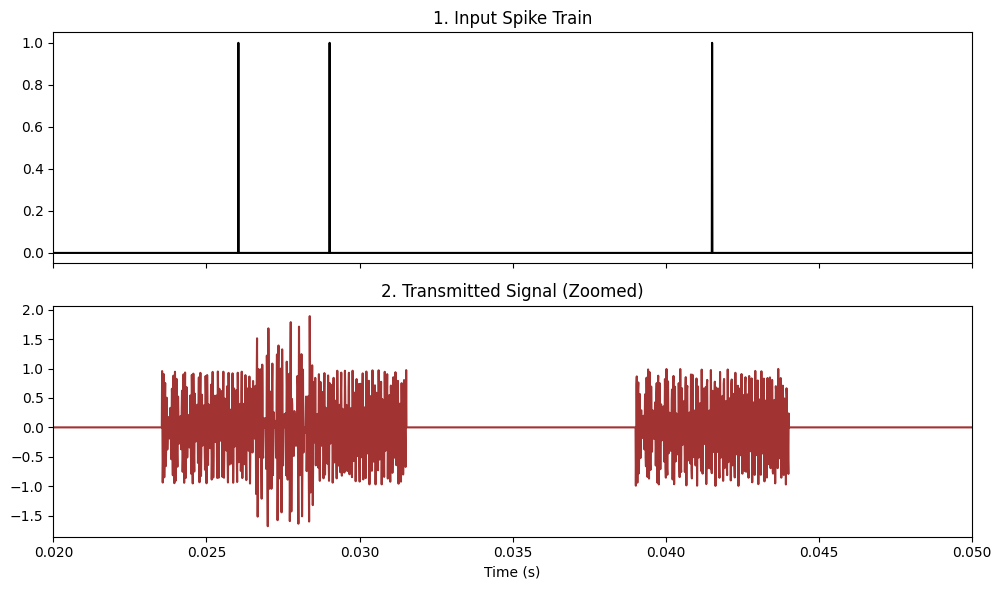

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- Parameters ---
fs = 100000       # Sampling Rate (Hz)
T = 0.1           # Duration of simulation (seconds)
t_np = np.linspace(0, T, int(fs*T))

# Spike Generation Params
spike_prob = 0.02 # Probability of spike per millisecond
np.random.seed(42) # Fixed seed
raw_spikes_np = (np.random.rand(len(t_np)) < (spike_prob * 1000 / fs)).astype(float)

# Radar Chirp Params
chirp_duration = 0.005 # 5ms chirp
bw = 5000              # Bandwidth of chirp (5 kHz)
f_start = 1000         # Start Freq (1 kHz)
t_chirp_np = np.linspace(0, chirp_duration, int(fs*chirp_duration))
chirp_template_np = signal.chirp(t_chirp_np, f0=f_start, f1=f_start+bw, t1=chirp_duration, method='linear')

# Carrier Params
f_carrier = 20000      # 20 kHz Carrier

# --- 1. Sifting Theorem (Convolution) ---
baseband_signal_np = signal.convolve(raw_spikes_np, chirp_template_np, mode='same')

# --- 2. Modulation (Put on Carrier) ---
carrier_np = np.cos(2 * np.pi * f_carrier * t_np)
tx_signal_np = baseband_signal_np * carrier_np

# --- Plotting (Zoomed) ---
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(t_np, raw_spikes_np, color='black')
ax[0].set_title("1. Input Spike Train")
ax[0].set_xlim(0.02, 0.05) # Zoom in to see spikes

ax[1].plot(t_np, tx_signal_np, color='darkred', alpha=0.8)
ax[1].set_title(f"2. Transmitted Signal (Zoomed)")
ax[1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

### Cell 2: The Complex Channel (Multi-Target & Doppler)

This is the core of the experiment. We simulate two echoes and add them together.

Echo 1 (Wall): A simple delayed and attenuated copy.

Echo 2 (Post): A delayed, attenuated copy, but its carrier frequency is shifted due to the Doppler effect.

The receiver adds these together, along with noise.

--- Doppler Effect ---
Target 2 Velocity: 10.0 m/s
Original Carrier: 20000 Hz
Doppler Shift: 1166.18 Hz
Shifted Carrier: 18833.82 Hz


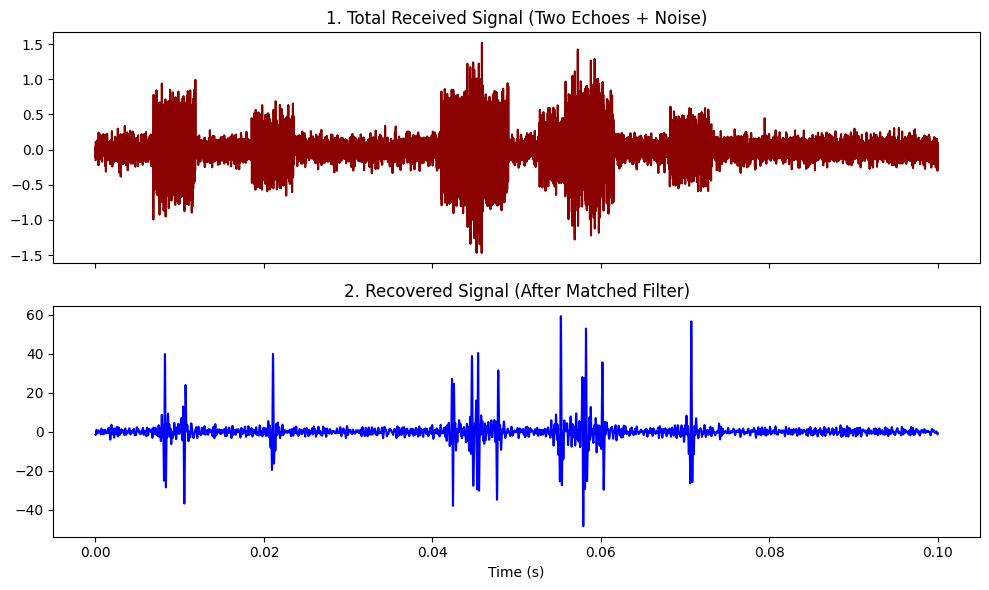

In [2]:
# --- 1. Environment & Physics Setup ---
c = 343  # Speed of sound (m/s)

# --- Target 1 (Stationary Wall) ---
dist_1 = 5.0  # 5.0 meters
vel_1 = 0.0   # 0 m/s
attn_1 = 0.5  # Attenuation

# --- Target 2 (Moving Post) ---
dist_2 = 3.0  # 3.0 meters
vel_2 = 10.0  # 10 m/s (Moving away, positive velocity)
attn_2 = 0.8  # Closer, so less attenuation

# --- 2. Calculate Echo 1 (Stationary) ---
tof_1 = (2 * dist_1) / c
delay_samples_1 = int(tof_1 * fs)
echo_1 = np.roll(tx_signal_np, delay_samples_1) * attn_1

# --- 3. Calculate Echo 2 (Doppler Shifted) ---
# Calculate Time of Flight
tof_2 = (2 * dist_2) / c
delay_samples_2 = int(tof_2 * fs)

# Calculate Doppler Shift
# f_d = 2 * v * f_c / c
doppler_shift = (2 * vel_2 * f_carrier) / c
shifted_carrier_freq = f_carrier - doppler_shift # Moving away, so freq decreases
print(f"--- Doppler Effect ---")
print(f"Target 2 Velocity: {vel_2} m/s")
print(f"Original Carrier: {f_carrier} Hz")
print(f"Doppler Shift: {doppler_shift:.2f} Hz")
print(f"Shifted Carrier: {shifted_carrier_freq:.2f} Hz")

# Re-create the transmitted signal, but with the *shifted* carrier
shifted_carrier_np = np.cos(2 * np.pi * shifted_carrier_freq * t_np)
tx_signal_shifted = baseband_signal_np * shifted_carrier_np
echo_2 = np.roll(tx_signal_shifted, delay_samples_2) * attn_2

# --- 4. Total Received Signal ---
noise = np.random.normal(0, 0.1, len(t_np))
rx_signal = echo_1 + echo_2 + noise

# --- 5. The "Simple" Receiver (Demodulate & Matched Filter) ---
# The receiver ONLY knows about the original f_carrier
demod_raw = rx_signal * carrier_np # Demodulate with original carrier
sos = signal.butter(10, f_carrier, 'low', fs=fs, output='sos')
rx_baseband = signal.sosfilt(sos, demod_raw)

# Run the matched filter ("Reverse System")
matched_filter = chirp_template_np[::-1]
recovered_signal = signal.convolve(rx_baseband, matched_filter, mode='same')

# --- Plotting ---
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(t_np, rx_signal, color='darkred')
ax[0].set_title("1. Total Received Signal (Two Echoes + Noise)")

ax[1].plot(t_np, recovered_signal, color='blue')
ax[1].set_title("2. Recovered Signal (After Matched Filter)")
ax[1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

### Cell 3: The Analysis (Finding Two Peaks)

This cell is nearly identical to our original 1D analysis. We run the cross-correlation to find the time delay. The difference is in the interpretation.

You will see a sharp, strong peak corresponding to the stationary target. You will also see a second, weaker and broader peak. This is the Doppler-shifted target. Our simple matched filter can still see it (proving robustness!), but the signal is badly degraded because of the frequency mismatch.

--- RESULTS ---
ACTUAL Distances: 5.0m (Stationary), 3.0m (Moving)
Detected 4 targets.
  Target 1: Calculated Distance = 0.55 m (at 3.18 ms)
  Target 2: Calculated Distance = 2.35 m (at 13.72 ms)
  Target 3: Calculated Distance = 5.01 m (at 29.20 ms)
  Target 4: Calculated Distance = 7.15 m (at 41.69 ms)


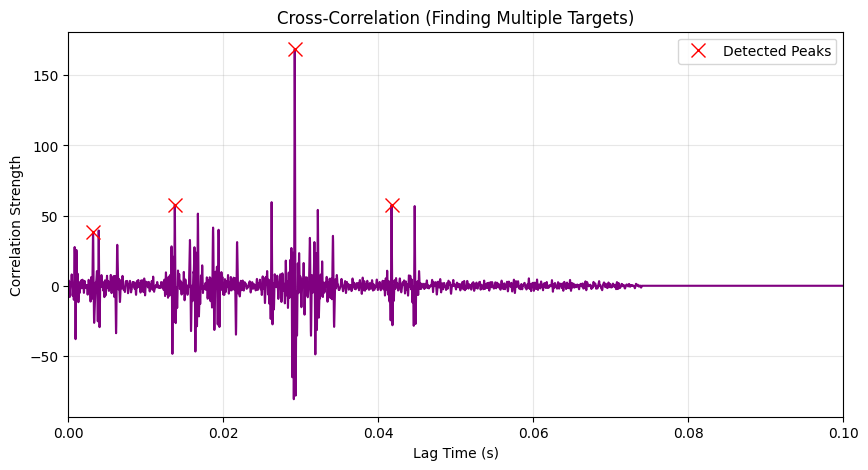

In [3]:
# --- 1. Cross-Correlation ---
# Correlate the recovered *analog* signal with the *original* spikes
# This finds "where did the spikes I sent show up in the return?"
correlation = signal.correlate(recovered_signal, raw_spikes_np, mode='full')
lags = signal.correlation_lags(len(recovered_signal), len(raw_spikes_np), mode='full')

# --- 2. Find Peaks (Constrained Search) ---
positive_lags_mask = (lags >= 0)
valid_lags = lags[positive_lags_mask]
valid_corr = correlation[positive_lags_mask]

# Find the 2 strongest peaks (using scipy.signal.find_peaks)
peak_indices, properties = signal.find_peaks(valid_corr, height=np.max(valid_corr)*0.2, distance=fs*0.01)
peak_lags = valid_lags[peak_indices]
peak_times = peak_lags / fs

# --- 3. Calculate Distances ---
calculated_distances = (c * peak_times) / 2

print(f"--- RESULTS ---")
print(f"ACTUAL Distances: {dist_1}m (Stationary), {dist_2}m (Moving)")
print(f"Detected {len(peak_times)} targets.")
for i, (dist, t) in enumerate(zip(calculated_distances, peak_times)):
    print(f"  Target {i+1}: Calculated Distance = {dist:.2f} m (at {t*1000:.2f} ms)")

# --- Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
lag_time = lags / fs
ax.plot(lag_time, correlation, color='purple')

# Plot detected peaks
ax.plot(peak_times, valid_corr[peak_indices], "x", color='red', markersize=10, label="Detected Peaks")
ax.set_title("Cross-Correlation (Finding Multiple Targets)")
ax.set_xlabel("Lag Time (s)")
ax.set_ylabel("Correlation Strength")
ax.set_xlim(0, T)
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()